# Ejercicio 2 — Impacto de inundación de una tormenta del conjunto

Un conjunto de 198 tormentas simuladas, cada una con su propio mapa de profundidad
de inundación. Este cuaderno toma una tormenta de ese conjunto y calcula qué toca
realmente su inundación: qué tan profunda llega el agua sobre cada edificio y cada
carretera, y cuántas personas, cuánta superficie construida y cuántos kilómetros de
carretera suma eso.

La pregunta que se responde es:

> **En la tormenta 150, ¿qué tan profunda es el agua sobre cada edificio y cada
> carretera?**

La profundidad es una cantidad física, así que la respuesta no necesita ningún
umbral. Vale la pena contrastarlo con el Ejercicio 3, que trabaja con
*probabilidades* y por eso sí necesita uno.

**Qué llevarse de este cuaderno**

- cómo leer un solo corte de un almacén Zarr grande sin descargar todo el arreglo
- cómo muestrear un ráster sobre miles de polígonos en una sola pasada, y por qué
  el *máximo* sobre la huella del edificio es aquí la opción defendible
- de dónde sale cada número de una tabla de impacto, y qué decisiones del camino lo
  cambian

**Flujo de trabajo**

1. Abrir el conjunto de tormentas y mirar una de ellas
2. Cargar los edificios y las carreteras
3. Muestrear el agua más profunda sobre la huella de cada edificio
4. Agrupar en bandas de profundidad y armar la tabla de impacto
5. Ver cómo crece el impacto a lo largo del conjunto

Todo se lee de un bucket público de S3. Nada se guarda localmente.

In [1]:
!pip install zarr


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
STORE = f"{BUCKET}/floodmaps_test"                             # el conjunto de tormentas
FEATURES = f"{BUCKET}/Guatemala_IBF/impact_features.geojson"   # edificios + carreteras

print("listo")

listo


## 1. El conjunto de tormentas

Los mapas de inundación viven en un **almacén Zarr**: piénselo como un arreglo
partido en muchos archivos pequeños, de modo que se puede leer un solo corte sin
descargarlo todo. Aquí el arreglo `depth` pesa unos 108 MB en total; nunca
necesitamos más de una tormenta a la vez.

El almacén trae sus propios metadatos. Léalos primero: le dicen dónde está, en qué
unidades trabaja y —lo más importante— de qué *no* debe fiarse.

In [3]:
import zarr
from zarr.storage import FsspecStore

group = zarr.open_group(FsspecStore.from_url(STORE), mode="r")
attrs = dict(group.attrs)

for key, value in attrs.items():
    print(f"{key:22} {value}")

crs                    EPSG:3857
transform              [5.0, 0.0, -10079319.926, 0.0, -5.0, 1630785.079]
extent_threshold_m     0.05
source_nodata          -3.4028234663852886e+38
magnitude_source       placeholder_rank_by_flooded_area_25_300mm
n_storms               200
grid_shape             [424, 319]
site                   SantaInesPetapa
country                Guatemala
library_source         RainyDay x hydraulic model, 200 samples
note                   magnitudes are placeholders; run attach_magnitudes() with real RainyDay 24-h totals


Tres cosas que hay que sacar de ahí:

- **`site` / `country`** — Santa Inés Petapa, Guatemala.
- **`extent_threshold_m: 0.05`** — el modelo no considera mojada una celda por
  debajo de 5 cm. Vamos a reutilizar ese número en lugar de inventar el nuestro.
- **`note`** — *"magnitudes are placeholders"* (las magnitudes son valores de
  relleno). Las tormentas se ordenaron por área inundada y luego se asignaron
  magnitudes de lluvia a esos puestos. Así que la cifra en "mm" de una tormenta es
  una etiqueta, **no lluvia medida**. Graficar el impacto contra ella parecería un
  hallazgo y en realidad sería circular. Vamos a graficar contra el *índice* de la
  tormenta.

`depth` está en **metros**, y `transform` + `crs` nos dicen dónde cae cada celda.

In [4]:
depth = group["depth"]
print(f"arreglo depth: forma {depth.shape}  tipo {depth.dtype}  bloques {depth.chunks}")
print(f"  -> {depth.nbytes / 1e6:.0f} MB en total, "
      f"{np.prod(depth.chunks) * 4 / 1e3:.0f} KB por tormenta")

STORM = 150               # pruebe cambiarlo: la 2 está casi seca, la 199 es la peor
one_storm = np.asarray(depth[STORM], dtype="float32")
one_storm = np.where(np.isfinite(one_storm) & (one_storm > 0), one_storm, 0.0)

wet = one_storm[one_storm >= attrs["extent_threshold_m"]]
print(f"\ntormenta {STORM}: {wet.size:,} celdas mojadas, "
      f"máximo {one_storm.max():.2f} m, media donde hay agua {wet.mean():.2f} m")

arreglo depth: forma (200, 424, 319)  tipo float32  bloques (1, 424, 319)
  -> 108 MB en total, 541 KB por tormenta



tormenta 150: 36,010 celdas mojadas, máximo 13.32 m, media donde hay agua 3.11 m


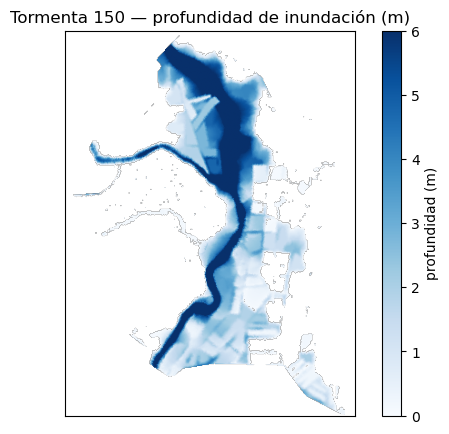

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
shown = np.where(one_storm >= attrs["extent_threshold_m"], one_storm, np.nan)
im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=6)
ax.set_title(f"Tormenta {STORM} — profundidad de inundación (m)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="profundidad (m)")
plt.show()

## 2. El resumen del conjunto

Calcular estadísticas por tormenta es barato para *una* tormenta, pero caro para las
200: eso significa leer los 108 MB completos. Por eso el resumen se **precalcula**
una sola vez y se publica junto al almacén como un CSV pequeño, y cualquier cosa que
necesite una cifra por tormenta lee ese archivo en lugar de los arreglos.

Es un patrón que vale la pena copiar: si hay que derivar una cifra de un conjunto de
datos grande, calcúlela una vez fuera de línea y no en cada solicitud.

In [6]:
stats = pd.read_csv(f"{STORE}/ensemble_stats.csv")
print(f"{len(stats)} filas — una por tormenta\n")
stats.head(3)

200 filas — una por tormenta



,storm_index,storm_id,magnitude_mm,flooded_px,area_km2,pct_domain,max_depth_m,mean_wet_depth_m
0,0,sample_0003,25.00,0,0.0000,0.00,0.000,0.000
1,1,sample_0004,26.38,0,0.0000,0.00,0.000,0.000
2,2,sample_0002,27.76,1667,0.0417,1.23,2.669,1.075


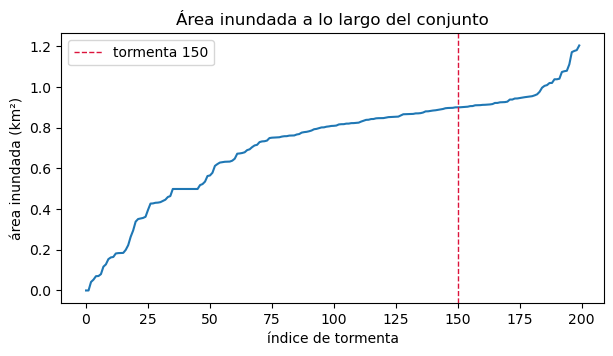

estrictamente no decreciente: True


In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(stats.storm_index, stats.area_km2, lw=1.5)
ax.axvline(STORM, color="crimson", ls="--", lw=1, label=f"tormenta {STORM}")
ax.set_xlabel("índice de tormenta"); ax.set_ylabel("área inundada (km²)")
ax.set_title("Área inundada a lo largo del conjunto")
ax.legend(); plt.show()

increasing = bool((stats.area_km2.diff().dropna() >= 0).all())
print(f"estrictamente no decreciente: {increasing}")

Esa curva sube de forma monótona porque el conjunto fue **ordenado por área
inundada**. Recorrer las tormentas, entonces, recorre la *severidad*.

Note también que las tormentas 0 y 1 están completamente secas: sus bloques nunca se
escribieron, porque Zarr omite los bloques que contienen solo el valor de relleno.
Por eso el rango utilizable empieza en 2.

## 3. Los edificios y las carreteras

Los datos de exposición son una copia reducida de un geopaquete IBF: solo los
elementos que llevan información de inundación, conservando la geometría para poder
mapearlos.

In [8]:
features = gpd.read_file(FEATURES)
print(f"{len(features):,} elementos  |  CRS {features.crs}")
print(features.tipo.value_counts().to_string())
print()
features[["tipo", "poblacion", "area_m2", "longitud_m"]].head(3)

5,147 elementos  |  CRS EPSG:32615
tipo
edificio     4689
carretera     458



,tipo,poblacion,area_m2,longitud_m
0,edificio,6.22,178.0,0.0
1,edificio,5.08,145.4,0.0
2,edificio,4.44,127.0,0.0


`poblacion` es la estimación de población **por edificio**. Una trampa que
conviene conocer: el geopaquete original también tiene una columna `Población` que
repite el total del *municipio* completo en cada edificio. Sumar esa columna
sobrestima la exposición en cuatro órdenes de magnitud. Verifique siempre si un
campo de población es un total o una desagregación.

## 4. Muestrear la profundidad sobre cada elemento

Queremos, para cada edificio, **el agua más profunda en cualquier punto de su
huella**. Es la lectura conservadora, y coincide con la forma en que se muestrearon
las probabilidades IBF del Ejercicio 3, así que los dos productos siguen siendo
comparables.

Hacerlo elemento por elemento sería lento. En su lugar:

1. **Rasterizar una sola vez**: grabar el *id* de cada elemento en una cuadrícula.
   Esto no depende de la tormenta, así que se paga una vez y se reutiliza para las
   200.
2. Para cada tormenta, tomar la profundidad máxima por id con `np.maximum.at`, que
   es una sola pasada sobre las celdas.

Los elementos están guardados en un CRS distinto al del conjunto, así que primero se
reproyectan a la cuadrícula del propio almacén: es barato, porque son datos
vectoriales.

`all_touched=True` significa que una celda cuenta si el elemento la toca en algún
punto, no solo si el centro de la celda cae dentro. Esto importa cuando los edificios
miden apenas unas pocas celdas.

In [9]:
zarr_transform = rasterio.Affine(*attrs["transform"])
rows, cols = attrs["grid_shape"]
features = features.to_crs(attrs["crs"])

ids = rasterize(
    ((geom, i + 1) for i, geom in enumerate(features.geometry)),
    out_shape=(rows, cols),
    transform=zarr_transform,
    fill=0,
    all_touched=True,
    dtype="int32",
)  # una cuadrícula de ids de elementos; 0 significa "ningún elemento"

in_domain = np.unique(ids)
in_domain = in_domain[in_domain > 0]
print(f"{int((ids > 0).sum()):,} de {ids.size:,} celdas están cubiertas por un elemento")
print(f"{len(in_domain):,} de {len(features):,} elementos caen en la cuadrícula "
      f"({100 * len(in_domain) / len(features):.1f}%)")

41,808 de 135,256 celdas están cubiertas por un elemento
5,029 de 5,147 elementos caen en la cuadrícula (97.7%)


**118 elementos quedan fuera del dominio del modelo.** El dominio mide solo
3.38 km² y el geopaquete se extiende más allá, así que esos elementos nunca pueden
reportarse como afectados, sea cual sea la tormenta. Cuando cite un porcentaje, diga
"de 5,029 dentro del dominio del modelo", no "de 5,147", o subestimará el impacto sin
darse cuenta.

In [10]:
def feature_max_depth(storm_index):
    """El agua más profunda sobre la huella de cada elemento, en metros."""
    layer = np.asarray(depth[storm_index], dtype="float32")
    # El valor nodata del almacén es un flotante negativo grande. Todo lo que no
    # sea finito, o sea negativo, es "sin agua", no una profundidad.
    layer = np.where(np.isfinite(layer) & (layer > 0), layer, 0.0)

    per_feature = np.zeros(len(features) + 1, dtype="float32")
    np.maximum.at(per_feature, ids.ravel(), layer.ravel())
    return per_feature[1:]      # descarta el índice 0: las celdas sin elemento


depths = feature_max_depth(STORM)
print(f"tormenta {STORM}: {int((depths >= 0.05).sum()):,} elementos tocados por el agua")
print(f"  elemento más profundo: {depths.max():.2f} m")

tormenta 150: 2,792 elementos tocados por el agua
  elemento más profundo: 13.16 m


## 5. Bandas de profundidad

Ahora agrupamos las profundidades en bandas. Son números redondos, elegidos para que
cada uno se entienda sin leyenda: aproximadamente el tobillo, la rodilla y por encima
de la cabeza. El piso de 0.05 m es el propio `extent_threshold_m` del almacén, no un
número que hayamos inventado.

Se asignan en orden **ascendente** y las asignaciones posteriores ganan, de modo que
cada elemento termina en la banda más profunda que alcanza.

In [11]:
DEPTH_BANDS = [          # (valor de clase, color, límite inferior en metros)
    (1, "green", 0.05),
    (2, "yellow", 0.30),
    (3, "red", 1.00),
    (4, "purple", 2.00),
]
BAND_LABEL = {1: "0.05 - 0.3 m", 2: "0.3 - 1 m", 3: "1 - 2 m", 4: "2 m o más"}


def classify_depth(values):
    band = np.zeros(len(values), dtype="uint8")     # 0 = seco
    for value, _colour, floor in DEPTH_BANDS:
        band[values >= floor] = value               # gana la banda más profunda
    return band


features["depth_m"] = depths
features["band"] = classify_depth(depths)
features["level"] = features.band.map(BAND_LABEL)

features.band.value_counts().sort_index().rename(BAND_LABEL).rename_axis("banda")

banda
0               2355
0.05 - 0.3 m     329
0.3 - 1 m        411
1 - 2 m          618
2 m o más       1434
Name: count, dtype: int64

> ⚠️ **Clasifique antes de redondear.** Si primero redondea las profundidades a 2
> decimales y *después* clasifica, los elementos que están en 0.0455 m se redondean a
> 0.05 y ascienden a la banda mojada. Eso es un asunto de presentación cambiando la
> respuesta en silencio: nos movió 14 elementos cuando nos pasó de verdad. Redondee
> solo lo que imprime.

## 6. La tabla de impacto

La banda más profunda va primero, para que el peor caso se lea primero, con un total
sobre todos los elementos afectados.

In [12]:
TOTAL_POPULATION = 290_868   # todos los edificios del geopaquete, para la proporción


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Profundidad": name,
        "Edificios": f"{len(buildings):,}",
        "Población": f"{group.poblacion.sum():,.0f}",
        "Área (m²)": f"{group.area_m2.sum():,.0f}",
        "Carreteras (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% de la población": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


affected = features[features.band > 0]
# Ojo: no usar `rows` -- ese nombre ya guarda la altura de la cuadrícula.
table_rows = [impact_row(BAND_LABEL[v], affected[affected.band == v])
              for v, _c, _f in reversed(DEPTH_BANDS)]
table_rows.append(impact_row("TOTAL afectado", affected))

pd.DataFrame(table_rows).set_index("Profundidad")

,Edificios,Población,Área (m²),Carreteras (km),% de la población
Profundidad,,,,,
2 m o más,"1,265","3,344","109,097",22.1,1.15%
1 - 2 m,553,"1,477","48,238",4.2,0.51%
0.3 - 1 m,365,"1,308","43,000",2.4,0.45%
0.05 - 0.3 m,295,825,"46,224",3.8,0.28%
TOTAL afectado,"2,478","6,955","246,558",32.5,2.39%


## 7. Mapearlo

Los elementos afectados, coloreados por banda de profundidad, dibujados sobre el
ráster de profundidad.

/tmp/ipykernel_62456/2234842269.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


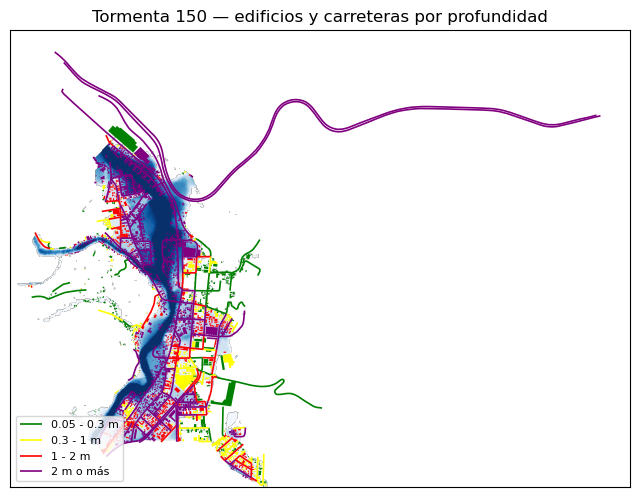

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
extent = rasterio.transform.array_bounds(rows, cols, zarr_transform)
ax.imshow(shown, cmap="Blues", vmin=0, vmax=6,
          extent=(extent[0], extent[2], extent[1], extent[3]))

for value, colour, _floor in DEPTH_BANDS:
    subset = features[features.band == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, label=BAND_LABEL[value])

ax.set_title(f"Tormenta {STORM} — edificios y carreteras por profundidad")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

Solo se dibujan los elementos que alcanzan alguna banda. Los secos son la gran
mayoría y no agregan nada que un mapa base no muestre ya; descartarlos también baja
la carga de unos 2 MB a unos pocos cientos de KB, lo que importa cuando se vuelve a
consultar cada vez que cambia la tormenta.

## 8. Cómo lo hace el módulo del tablero

Todo lo anterior corre aquí, en un cuaderno. Para llevarlo a un tablero, el mismo
código tiene que convertirse en un **módulo**: un paquete de Python
instalable que TethysDash encuentra por su cuenta y que ejecuta código de Python
personalizado para la interfaz.

### Descubrimiento: cómo lo encuentra la aplicación

Un módulo es una clase registrada como **punto de entrada de Intake** en el
`pyproject.toml` de su paquete:

```toml
[project.entry-points."intake.drivers"]
wmo_storm_impact_summary_es = "tgf_wmo_plugins.storm_impact_summary:StormImpactSummaryES"
wmo_storm_impact_layer_es   = "tgf_wmo_plugins.storm_impact_layer:StormImpactLayerES"
wmo_storm_card_es           = "tgf_wmo_plugins.storm_card:StormCardES"
```

Una vez que el módulo está instalado con TethysDash, los usuarios pueden integrarlo
en sus propios tableros para ver los resultados.

### La clase: propiedades de descubrimiento, argumentos y un método

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class StormImpactSummaryES(TethysDashPlugin):

    # ---- descubrimiento: cómo lista y presenta este módulo la interfaz ----
    name = "wmo_storm_impact_summary_es"   # debe coincidir con el punto de entrada
    label = "Resumen de Impacto por Tormenta (Español)"   # la fila del desplegable
    group = "Mapas de Inundación (Español)"               # el encabezado donde va
    description = "Personas, edificios y carreteras por profundidad de inundación."
    tags = ["inundación", "impacto", "zarr", "tormenta", "tabla", "español"]

    # ---- qué tipo de visualización es ------------------------------------
    type = "table"
    # `type` elige el renderizador de la interfaz y, por lo tanto, dicta la
    # forma que run() debe devolver. Uno de: table, card, plotly, image, text,
    # variable_input, map, map_layer, custom.

    # ---- qué le pide la interfaz a quien arma el tablero ------------------
    args = {
        "index": STORM_OPTIONS,   # una lista de {"value", "label"} -> desplegable
        # "number" / "text" / "checkbox" / "date" -> el campo correspondiente
    }
    # Los *nombres* de los argumentos son el contrato: son las claves que un
    # tablero guarda, así que renombrar uno rompe en silencio todos los tableros
    # que ya lo usan. La interfaz deriva la etiqueta de cada campo del nombre,
    # separando por guiones bajos y capitalizando, así que `index` se muestra
    # como "Index".

    def run(self):
        """Se llama una vez por solicitud, y otra vez cuando cambia un argumento."""

        index = self.get_arg("index", 2)
        # get_arg() lee un valor configurado. Si quien armó el tablero vinculó
        # este argumento a una variable de entrada, la referencia "${Tormenta}"
        # ya está resuelta a esta altura: el módulo nunca ve la plantilla.

        gdf = banded_features(index)
        # ^ todo el cuaderno, secciones 3 a 5: cargar los elementos, muestrear el
        #   agua más profunda sobre cada huella y adjuntar una banda.

        # Un `table` devuelve un título y una lista de diccionarios de filas. Las
        # claves se vuelven las columnas, en orden; los valores son cadenas ya
        # formateadas, porque cómo debe leerse un número es una decisión que el
        # renderizador no puede tomar.
        return {"title": f"Tormenta {index}",
                "data": [{"Profundidad": "...", "Edificios": "..."}]}
```

Las dos variantes de idioma heredan de una misma clase base que contiene `run()`;
las subclases solo definen `name`, `label`, `group`, `tags` y qué tabla de textos
usar. Nada que calcule un número está duplicado.

### Las capas de mapa implementan dos métodos, no uno

A un módulo de tipo `map_layer` se le hacen dos preguntas distintas en dos momentos
distintos, así que las responde por separado:

```python
class StormImpactLayerES(TethysDashPlugin):
    name = "wmo_storm_impact_layer_es"
    label = "Capa de Impacto por Tormenta (Español)"
    group = "Mapas de Inundación (Español)"
    type = "map_layer"
    dynamic_map_layer = True     # esta bandera es la que habilita fetch_features()
    args = {"index": STORM_OPTIONS}

    def run(self):
        """Momento de CONFIGURACIÓN. Se llama una vez, al agregar la capa.

        Devuelve el *armazón* de la capa, no sus datos: un nombre, la vinculación
        de la fuente, las reglas de estilo y una leyenda. Es lo que llama el botón
        "Fetch plugin defaults" del editor de capas.
        """
        builder = LayerConfigurationBuilder("Edificios y carreteras inundados",
                                           "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NO self.args. self.args es el *esquema*; la reinvocación
        # en tiempo de ejecución necesita los *valores* configurados, incluida
        # cualquier vinculación "${Tormenta}" que todavía haya que resolver.

        builder.set_style(...)    # reglas sobre un atributo del elemento (`banda`)
        builder.set_legend(...)   # qué muestra la leyenda del mapa para esta capa
        return builder.build()    # -> el diccionario de configuración de la capa

    def fetch_features(self):
        """Momento de EJECUCIÓN. Al cargar, y cada vez que cambia `${Tormenta}`.

        Devuelve GeoJSON. Es la única parte que se vuelve a ejecutar.
        """
        self.send_update("Leyendo la tormenta...", percentage_complete=10)
        # send_update() envía el progreso al elemento por un WebSocket, para que
        # un recálculo de varios segundos se vea ocupado y no averiado.

        gdf = banded_features(self.get_arg("index", 2))
        return {"type": "FeatureCollection",
                "features": [...],                 # uno por elemento afectado
                "crs": {"type": "name",
                        "properties": {"name": "EPSG:3857"}}}
```

### Los tres módulos construidos sobre estos datos

| módulo | `type` | qué devuelve `run()` |
|---|---|---|
| `wmo_storm_impact_summary_*` | `table` | `{"title", "data": [filas]}` — la tabla de la sección 6 |
| `wmo_storm_impact_layer_*` | `map_layer` | un armazón de capa; después `fetch_features()` devuelve el GeoJSON de la sección 7 |
| `wmo_storm_card_*` | `card` | `{"data": [{"color", "label", "value", "icon"}]}` — cifras principales, sin título |

### Por qué vale la pena separar los dos métodos

`run()` se ejecuta una vez, cuando alguien está configurando el tablero.
`fetch_features()` se ejecuta con cada cambio de una variable vinculada. Poner el
estilo y la leyenda en `run()` significa que se calculan una sola vez y se guardan
con el tablero, así que cambiar la tormenta vuelve a ejecutar solo la parte que
realmente depende de la tormenta.

Los tres módulos importan el mismo módulo central, que guarda en caché el paso caro
que no depende de la tormenta. Rasterizar 5,147 elementos se paga una vez por
proceso; cambiar la tormenta vuelve a leer un bloque de unos 540 KB y hace una sola
pasada sobre las celdas.

### Cosas para probar

- Cambie `STORM` en la sección 1 y vuelva a ejecutar. La tormenta 2 está casi seca;
  la 199 es la peor del conjunto.
- Cambie los límites de `DEPTH_BANDS`. ¿Qué le pasa a la tabla si agrega una banda
  de `4 m o más`?
- Las cifras de población usan `TOTAL_POPULATION` (todos los edificios) como
  denominador. Vuelva a calcular los porcentajes usando solo los 5,029 elementos que
  están dentro del dominio del modelo. ¿Cuánto se mueve la respuesta?
- La sección 4 toma la profundidad **máxima** sobre cada huella. Pruebe con la media
  (`np.add.at` y un conteo) y vea cómo cambia la tabla. ¿Cuál es el número más
  defendible para dárselo a quien toma decisiones?